In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'legend.frameon': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '#000000',
    'legend.fancybox': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.linewidth': 1.5,
    'axes.grid': False,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'patch.linewidth': 1.5,
    'patch.edgecolor': '#000000',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'axes.edgecolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

In [2]:
import os
import random  
from PIL import Image, ImageEnhance  
from tensorflow.keras.preprocessing.image import load_img  
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.applications import VGG16  
from sklearn.utils import shuffle  

In [3]:
# Directories for training and testing data
train_dir = 'C:/Users/prass/Desktop/SEM 7/Soft_Project/MRI Images/Training'
test_dir = 'C:/Users/prass/Desktop/SEM 7/Soft_Project/MRI Images/Testing'

In [4]:
# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

In [5]:
print(f"Training samples: {len(train_paths)}, Test samples: {len(test_paths)}")


Training samples: 5712, Test samples: 1311


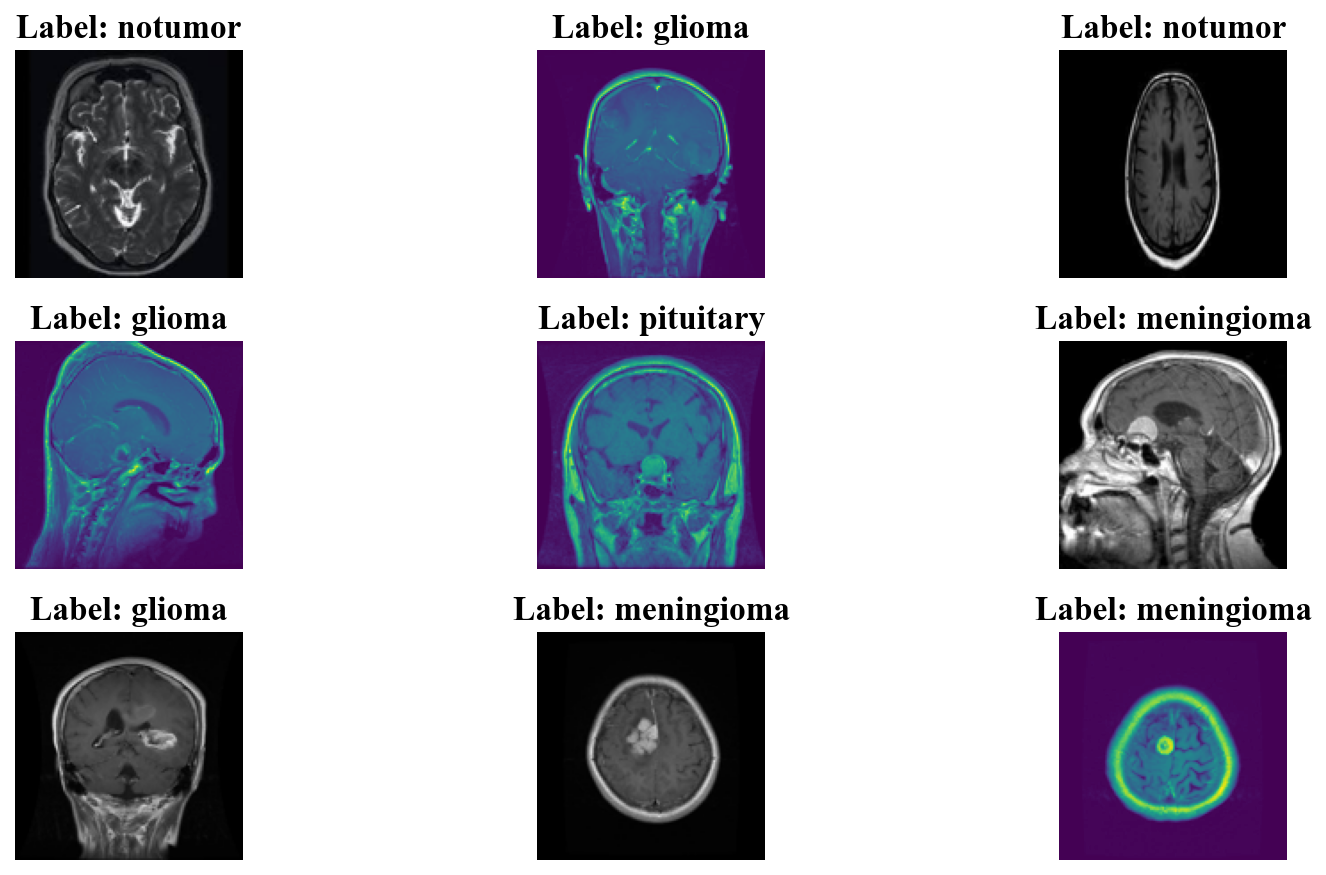

In [6]:
from PIL import Image

# Select random indices for 9 images
sample_indices = random.sample(range(len(train_paths)), 9)

plt.figure(figsize=(12, 6))

for i, sample_idx in enumerate(sample_indices):
    im = Image.open(train_paths[sample_idx]).resize((128, 128))
    
    plt.subplot(3, 3, i+1)   
    plt.imshow(im)  
    plt.axis("off")
    plt.title(f"Label: {train_labels[sample_idx]}")  

plt.tight_layout()
plt.show()


In [7]:
base_dir = "C:/Users/prass/Desktop/SEM 7/Soft_Project/MRI Images"

def get_class_counts(split):
    split_dir = os.path.join(base_dir, split)
    class_counts = {}
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

# Training counts
train_counts = get_class_counts("Training")

# Testing counts
test_counts = get_class_counts("Testing")

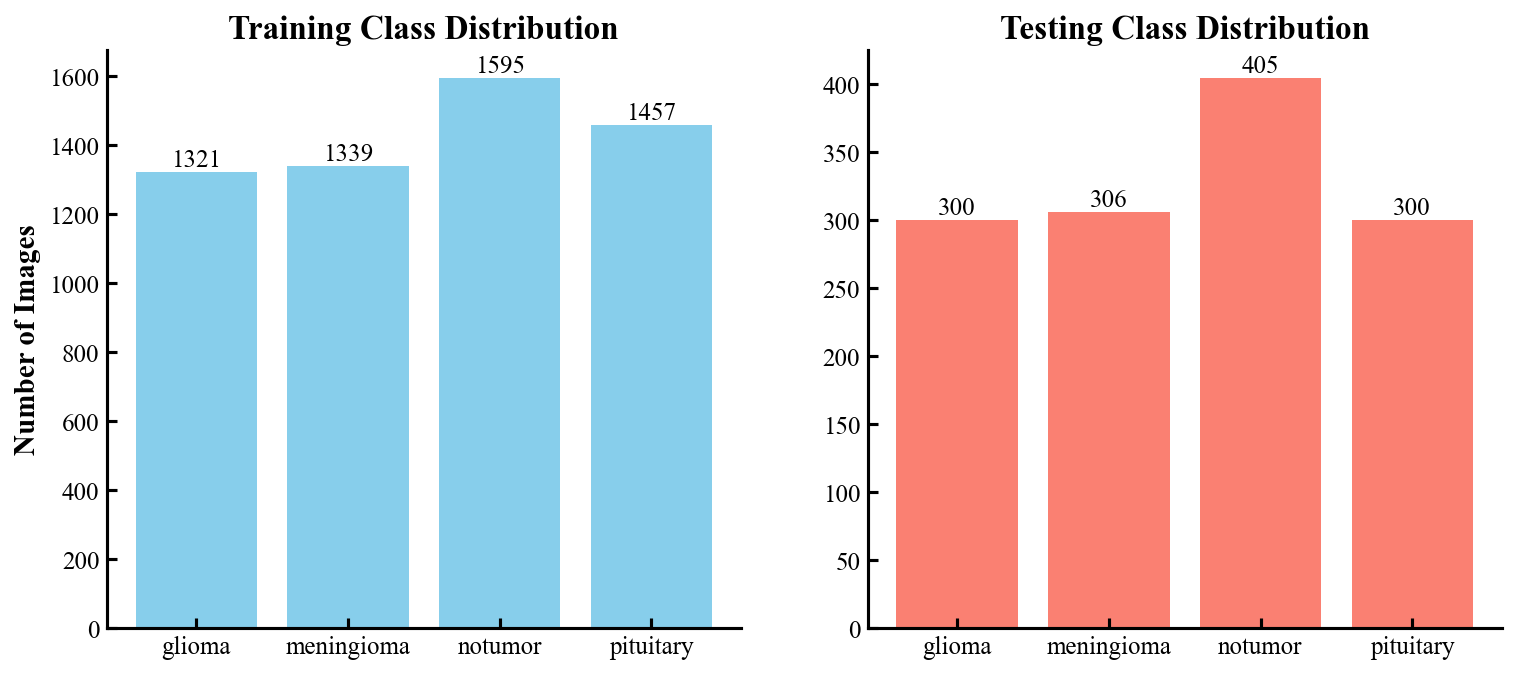

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training plot
bars1 = axes[0].bar(train_counts.keys(), train_counts.values(), color="skyblue")
axes[0].set_title("Training Class Distribution")
axes[0].set_ylabel("Number of Images")
axes[0].bar_label(bars1)   

# Testing plot
bars2 = axes[1].bar(test_counts.keys(), test_counts.values(), color="salmon")
axes[1].set_title("Testing Class Distribution")
axes[1].bar_label(bars2)   

plt.show()

In [9]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image


# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1, class_weights_dict=None):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            if class_weights_dict is not None:
                sample_weights = np.array([class_weights_dict[lbl] for lbl in batch_labels])
                yield batch_images, batch_labels, sample_weights
            else:
                yield batch_images, batch_labels

In [10]:
IMAGE_SIZE = 224 
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), 
    include_top=False, 
    weights='imagenet')

base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [11]:
for i, layer in enumerate(base_model.layers):
    print(f"Layer {i}: {layer.name}, Trainable: {layer.trainable}")

Layer 0: input_layer, Trainable: False
Layer 1: block1_conv1, Trainable: False
Layer 2: block1_conv2, Trainable: False
Layer 3: block1_pool, Trainable: False
Layer 4: block2_conv1, Trainable: False
Layer 5: block2_conv2, Trainable: False
Layer 6: block2_pool, Trainable: False
Layer 7: block3_conv1, Trainable: False
Layer 8: block3_conv2, Trainable: False
Layer 9: block3_conv3, Trainable: False
Layer 10: block3_pool, Trainable: False
Layer 11: block4_conv1, Trainable: False
Layer 12: block4_conv2, Trainable: False
Layer 13: block4_conv3, Trainable: False
Layer 14: block4_pool, Trainable: False
Layer 15: block5_conv1, Trainable: True
Layer 16: block5_conv2, Trainable: True
Layer 17: block5_conv3, Trainable: True
Layer 18: block5_pool, Trainable: True


In [12]:
# Build the transfer model
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 7,212,292 (27.51 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

batch_size = 32
train_steps = len(train_paths) // batch_size
val_steps = len(test_paths) // batch_size
epochs = 5

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights to handle imbalance
train_labels_encoded = encode_label(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_encoded),
    y=train_labels_encoded
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs, class_weights_dict=class_weights_dict),
    epochs=epochs,
    steps_per_epoch=train_steps,
    validation_data=datagen(test_paths, test_labels, batch_size=batch_size, epochs=epochs),
    validation_steps=val_steps,
    callbacks=[early_stop, reduce_lr]
)

Class weights: {0: np.float64(1.080999242997729), 1: np.float64(1.0664675130694548), 2: np.float64(0.8952978056426333), 3: np.float64(0.9800960878517502)}
Epoch 1/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.7045 - loss: 0.8003 - val_accuracy: 0.8484 - val_loss: 0.4770 - learning_rate: 1.0000e-04
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.8731 - loss: 0.3722 - val_accuracy: 0.8641 - val_loss: 0.3939 - learning_rate: 1.0000e-04
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.9180 - loss: 0.2355 - val_accuracy: 0.9015 - val_loss: 0.2758 - learning_rate: 1.0000e-04
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.9423 - loss: 0.1657 - val_accuracy: 0.9171 - val_loss: 0.2220 - learning_rate: 1.0000e-04
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.9607 - loss: 0.1158 - val_accuracy: 0.9304 - val_loss: 0.1779 - learning_rate: 1.0000e-04


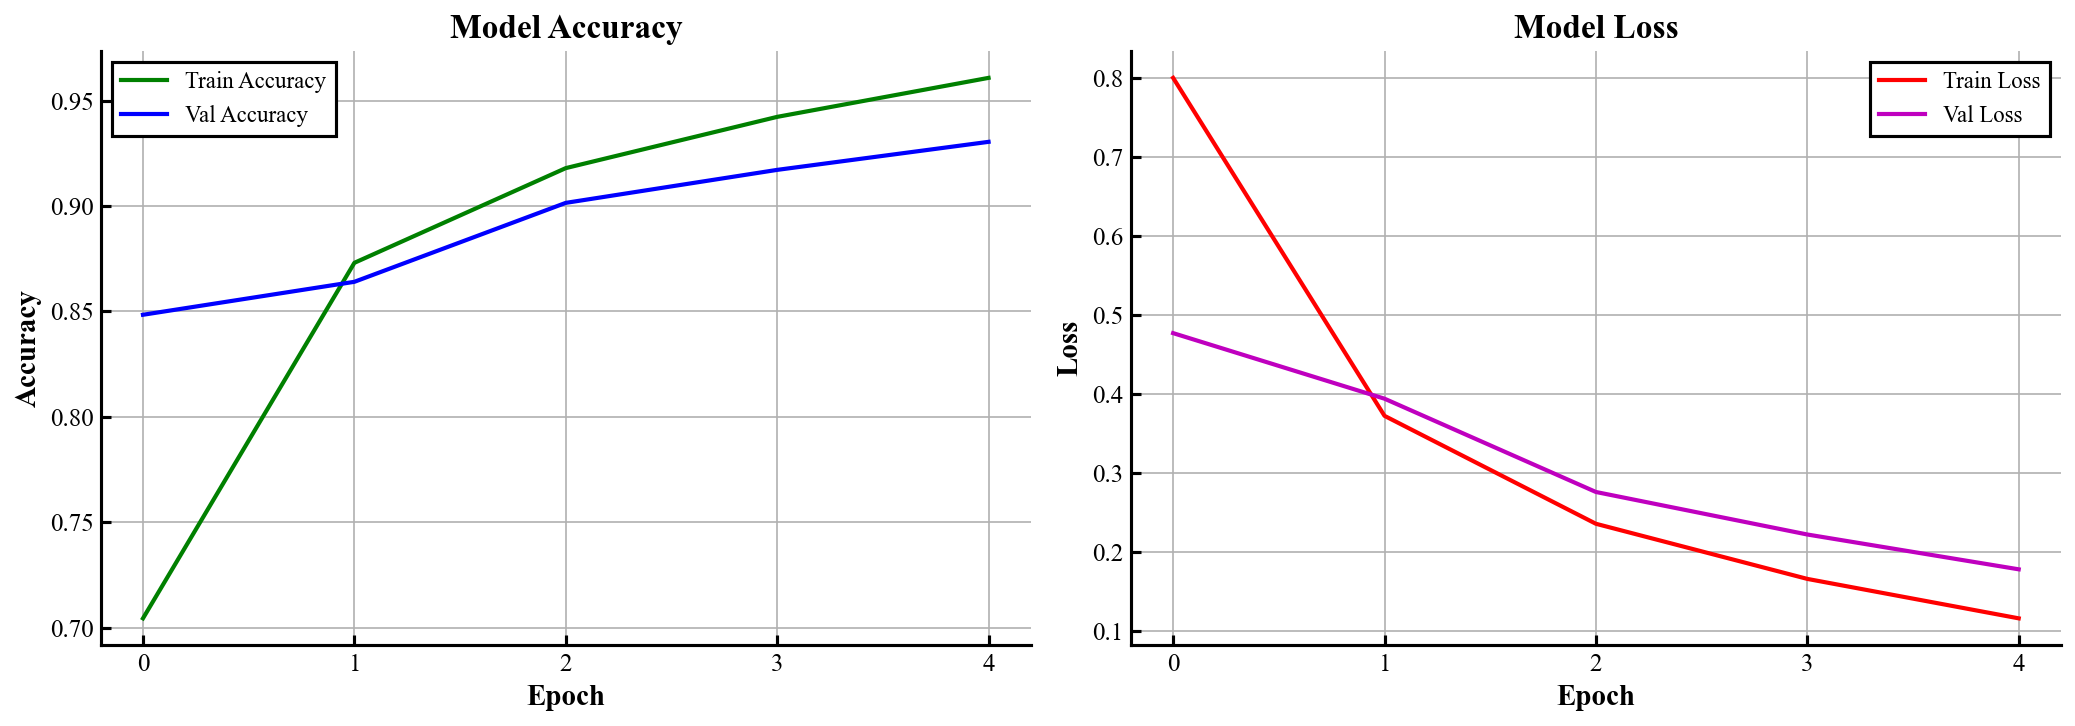

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'g-', linewidth=2, label='Train Accuracy')
plt.plot(history.history['val_accuracy'], 'b-', linewidth=2, label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(epochs))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'r-', linewidth=2, label='Train Loss')
plt.plot(history.history['val_loss'], 'm-', linewidth=2, label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(epochs))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       300
           1       0.95      0.80      0.87       306
           2       0.98      0.97      0.98       405
           3       0.96      0.95      0.95       300

    accuracy                           0.93      1311
   macro avg       0.93      0.93      0.92      1311
weighted avg       0.93      0.93      0.93      1311



Confusion Matrix:
[[296   4   0   0]
 [ 42 245   7  12]
 [  7   5 393   0]
 [ 11   4   1 284]]


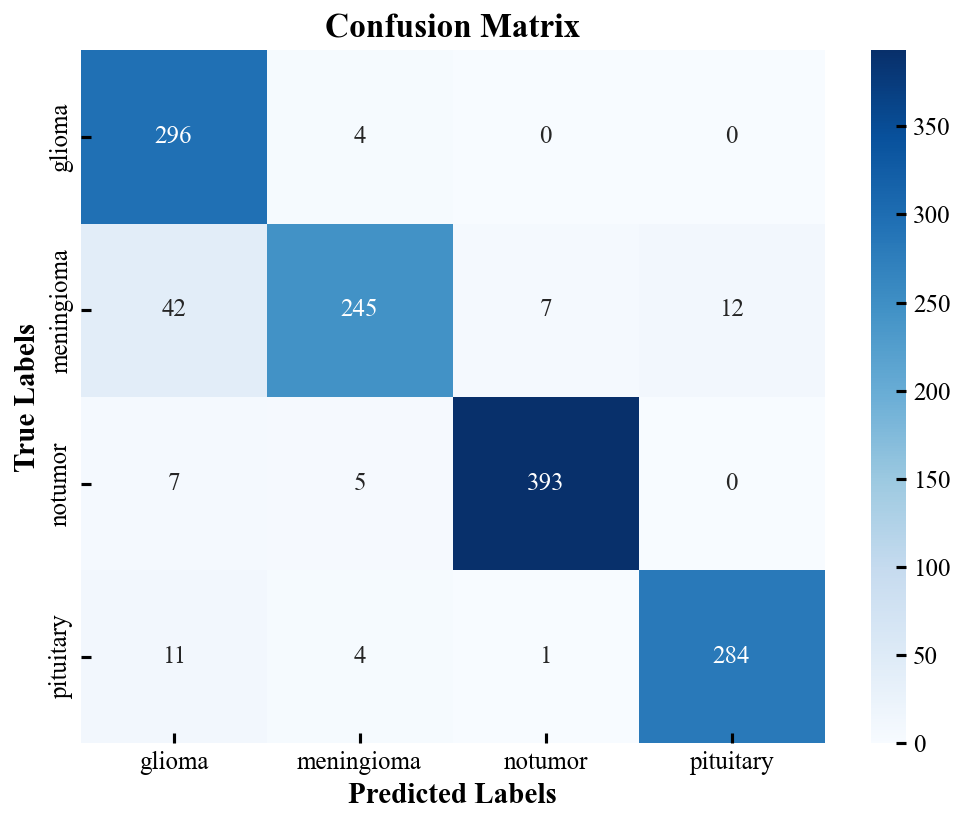

In [16]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

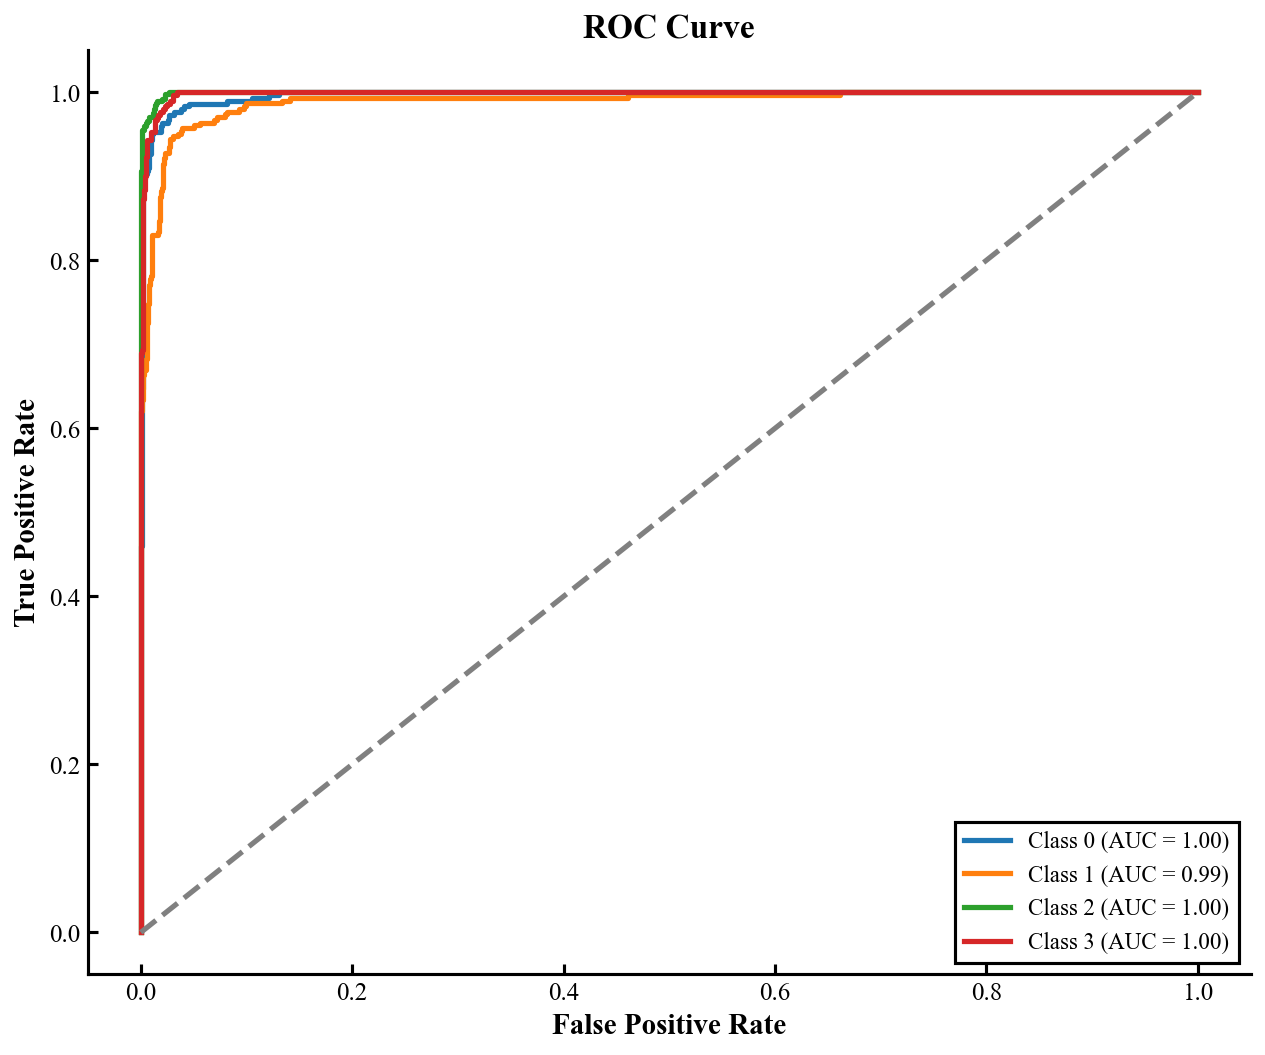

In [17]:
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model

# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [18]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from  tensorflow.keras.models import Model

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Get the VGG16 model (it's the first layer in the sequential model)
    vgg_base = model.layers[0]
    
    # 2. Extract the specific feature map from within VGG16
    last_conv_layer = vgg_base.get_layer(last_conv_layer_name)
    
    # 3. Create a model that goes from VGG input to VGG's last_conv_layer output AND to VGG's final output
    vgg_output_extractor = tf.keras.models.Model(
        inputs=vgg_base.inputs,
        outputs=[last_conv_layer.output, vgg_base.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, vgg_preds = vgg_output_extractor(img_array)
        
        # Pass vgg_preds through the rest of the Sequential model manually
        x = vgg_preds
        for layer in model.layers[1:]:
            x = layer(x)
            
        preds = x
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def visualize_tumor_and_get_stats(img_path, model, last_conv_layer_name="block5_conv3"):
    img = load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = augment_image(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_array)
    pred_index = np.argmax(preds[0])
    unique_labels = os.listdir(train_dir)
    pred_class = unique_labels[pred_index]
    confidence = preds[0][pred_index]
    
    heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index)
    
    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, (IMAGE_SIZE, IMAGE_SIZE))
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    superimposed_img = heatmap_colored * 0.4 + original_img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
    
    _, binary_mask = cv2.threshold(heatmap_resized, 128, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    x, y, w, h = 0, 0, 0, 0
    area = 0
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cv2.rectangle(superimposed_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title(f'Original (True: {os.path.basename(os.path.dirname(img_path))})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title('Grad-CAM Heatmap (Tumor Mask)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f'Tumor Detected: Y\nLocation: ({x},{y}), Size: {area} px\nClass: {pred_class} ({confidence:.2f})')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return {
        "tumor_detected": bool(contours),
        "class_type": pred_class,
        "confidence": float(confidence),
        "location": (x, y, w, h),
        "size_pixels": float(area)
    }


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


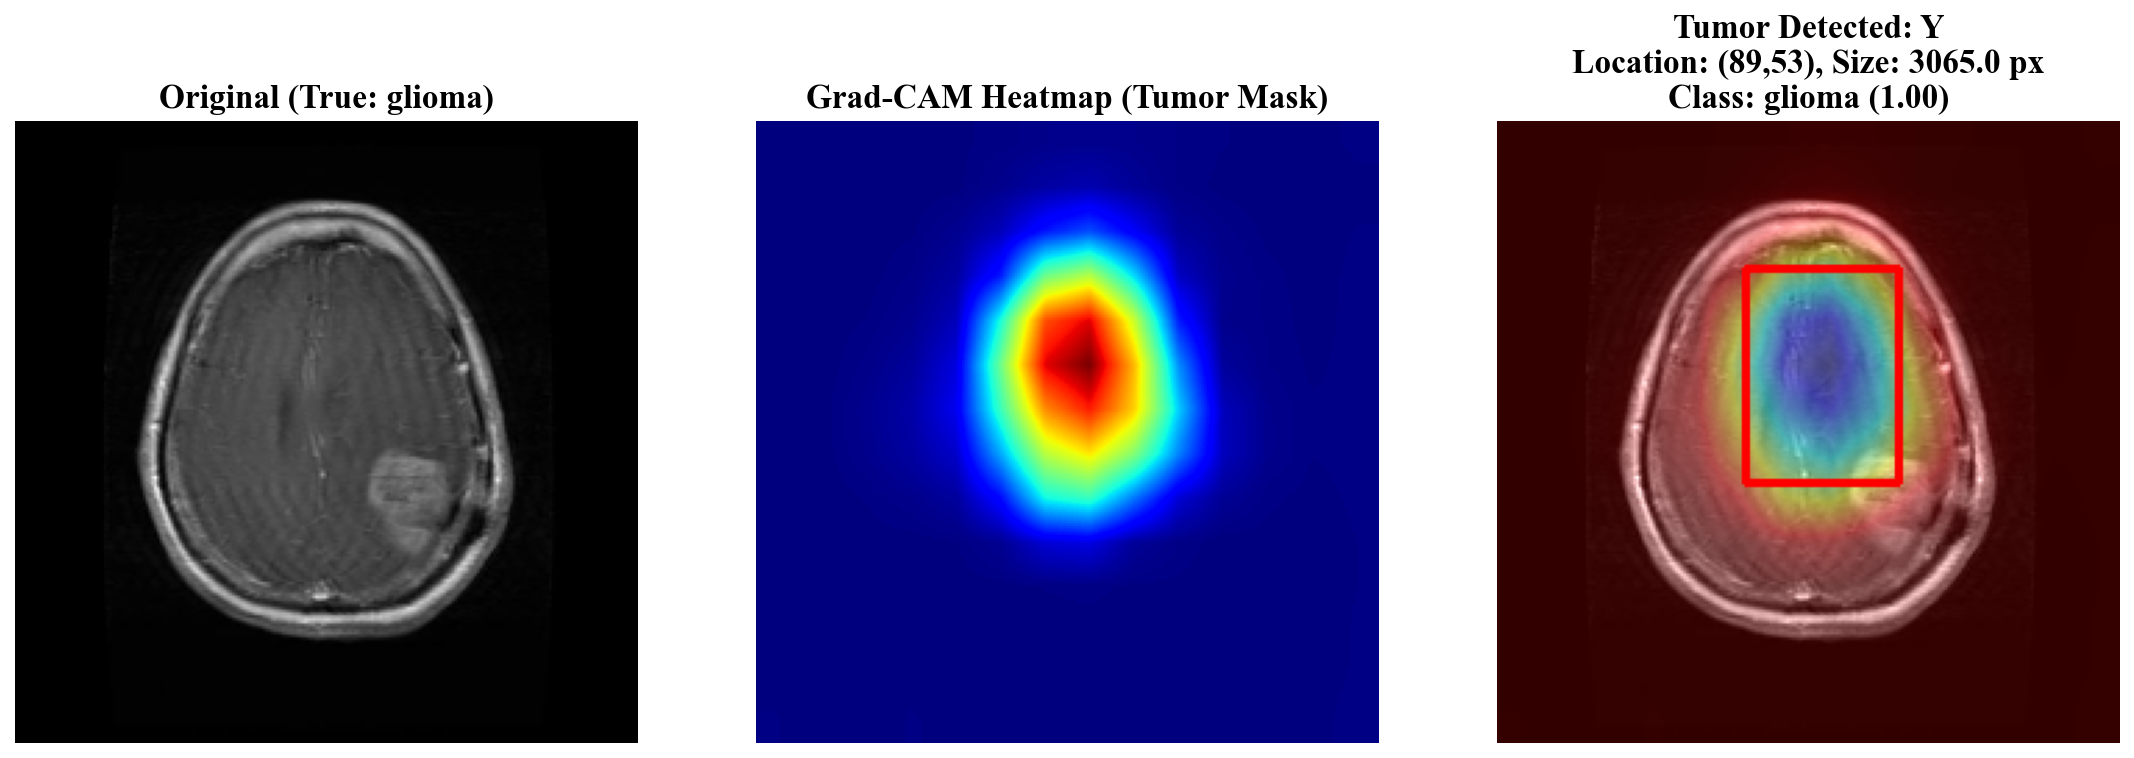

Results for Te-gl_0023.jpg: {'tumor_detected': True, 'class_type': 'glioma', 'confidence': 0.9998284578323364, 'location': (89, 53, 55, 77), 'size_pixels': 3065.0}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


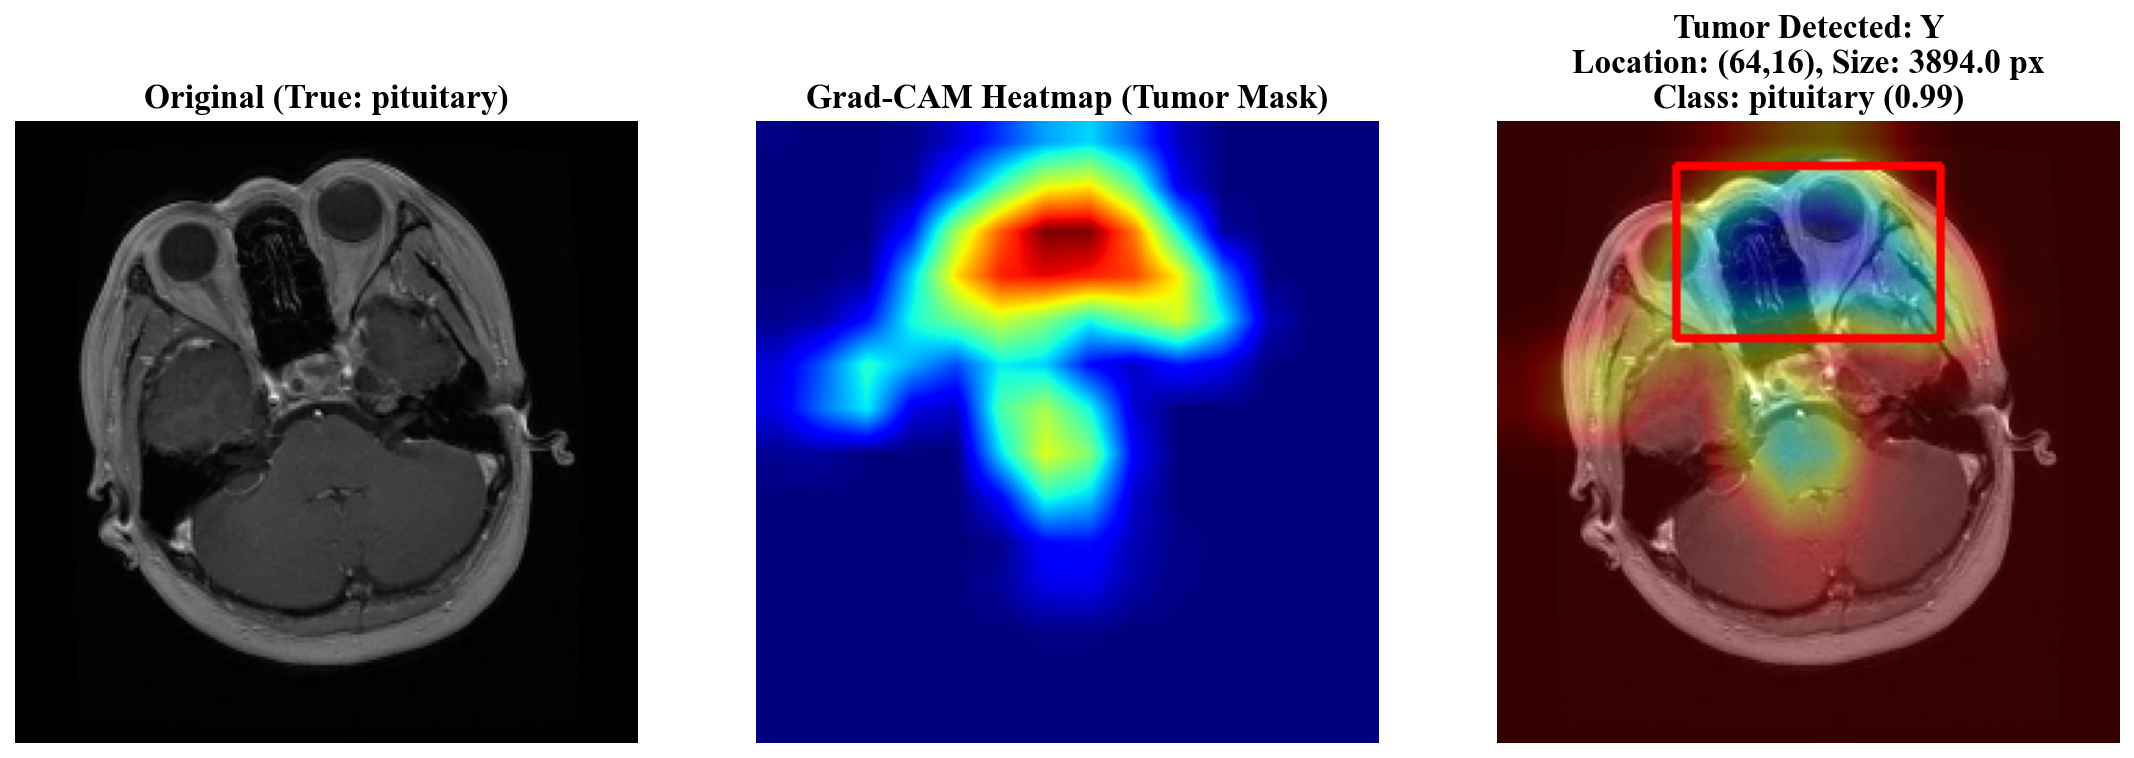

Results for Te-pi_0012.jpg: {'tumor_detected': True, 'class_type': 'pituitary', 'confidence': 0.993334174156189, 'location': (64, 16, 95, 62), 'size_pixels': 3894.0}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


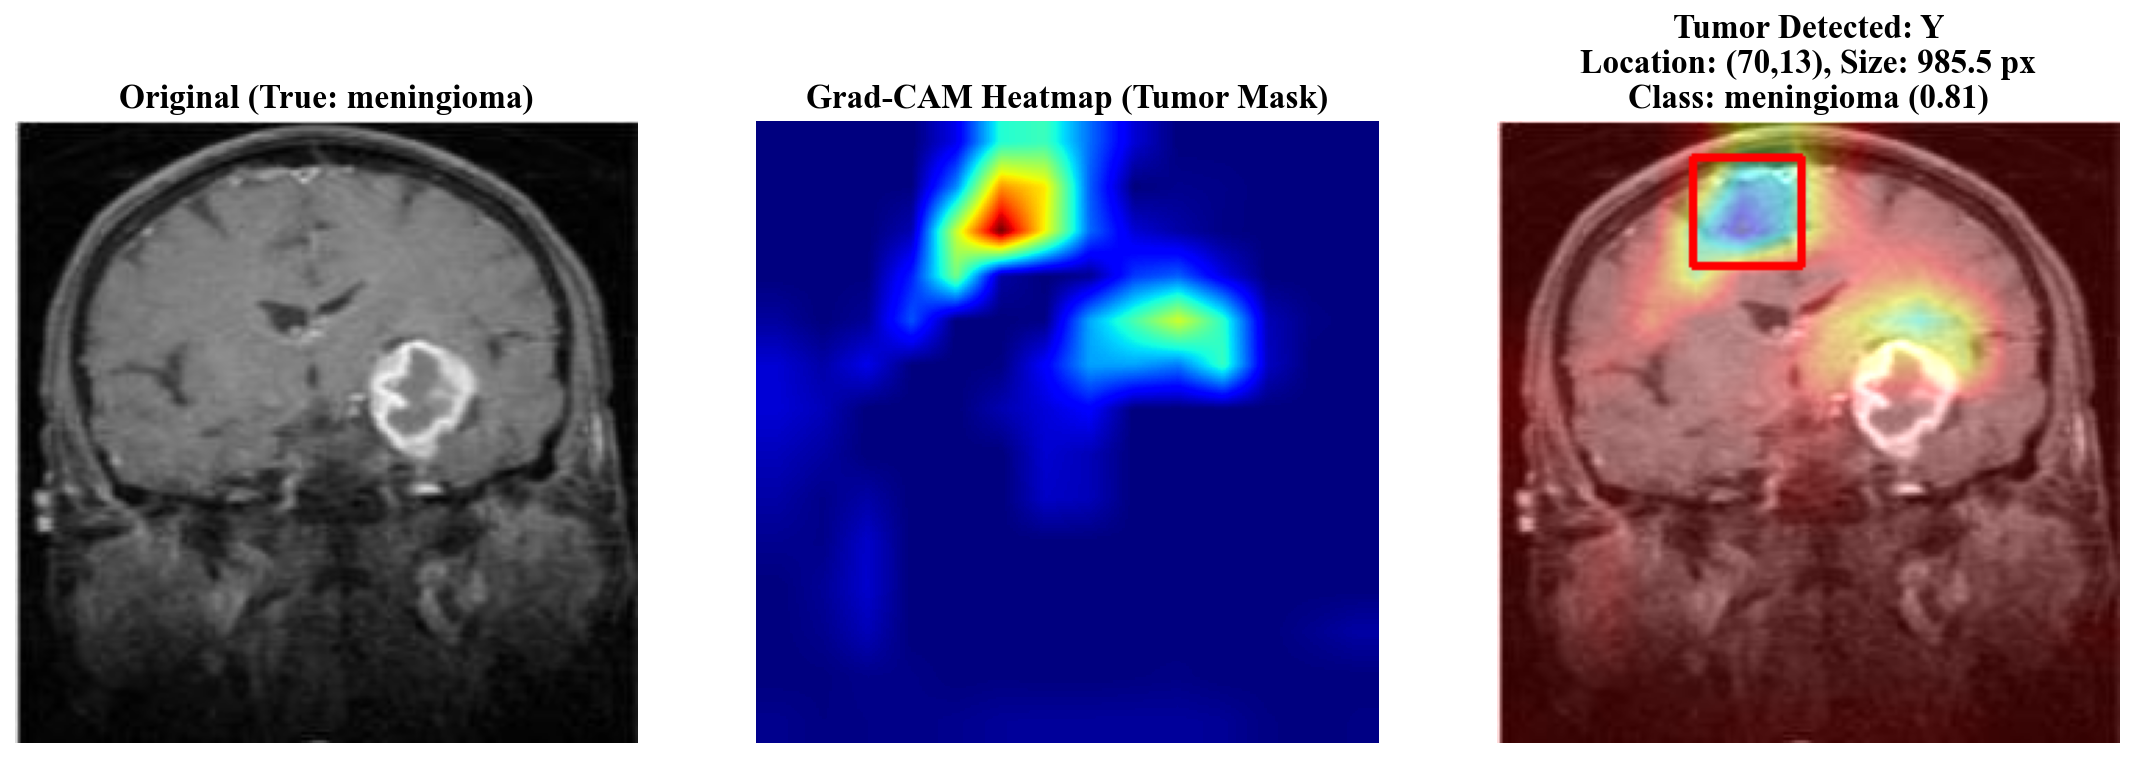

Results for Te-me_0064.jpg: {'tumor_detected': True, 'class_type': 'meningioma', 'confidence': 0.8107973337173462, 'location': (70, 13, 39, 39), 'size_pixels': 985.5}


In [19]:
# Test the explainable AI and mask generation on a few test images
sample_test_indices = random.sample(range(len(test_paths)), 3)
for idx in sample_test_indices:
    results = visualize_tumor_and_get_stats(test_paths[idx], model)
    print(f"Results for {os.path.basename(test_paths[idx])}:", results)


In [27]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Lambda, Input
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Build ResNet50 Model
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

for layer in resnet_base.layers:
    layer.trainable = False

resnet_model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    Lambda(lambda x: resnet_preprocess(x * 255.0)),
    resnet_base,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])

resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

resnet_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [30]:
# Train ResNet50 Model
print("Training ResNet50...")
resnet_history = resnet_model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=train_steps,
    validation_data=datagen(test_paths, test_labels, batch_size=batch_size, epochs=epochs),
    validation_steps=val_steps,
    callbacks=[early_stop, reduce_lr]
    # Removed class_weight as it is handled by our custom datagen
)


Training ResNet50...
Epoch 1/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.7302 - loss: 0.7737 - val_accuracy: 0.7961 - val_loss: 0.5413 - learning_rate: 5.0000e-05
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.7609 - loss: 0.6859 - val_accuracy: 0.8023 - val_loss: 0.5240 - learning_rate: 5.0000e-05
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.7766 - loss: 0.6319 - val_accuracy: 0.8124 - val_loss: 0.5007 - learning_rate: 5.0000e-05
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.7917 - loss: 0.6005 - val_accuracy: 0.8233 - val_loss: 0.4761 - learning_rate: 5.0000e-05
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8019 - loss: 0.5686 - val_accuracy: 0.8280 - val_loss: 0.4501 - learning_rate: 5.0000e-05


In [32]:
from sklearn.metrics import classification_report, accuracy_score

def predict_ensemble(img_batch, model1, model2, weight1=0.5, weight2=0.5):
    """Predicts using soft voting ensemble"""
    preds1 = model1.predict(img_batch, verbose=0)
    preds2 = model2.predict(img_batch, verbose=0)
    
    # Soft voting: weighted average of probabilities
    ensemble_preds = (preds1 * weight1) + (preds2 * weight2)
    return ensemble_preds

print("Evaluating Ensemble Model on Test Set...")

# Get predictions for the entire test set
y_true = []
y_pred_ensemble = []
y_pred_vgg = []

unique_labels = os.listdir(train_dir)
for i in range(len(test_paths)):
    img = load_img(test_paths[i], target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = augment_image(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Ensemble Prediction
    ens_probs = predict_ensemble(img_array, model, resnet_model)
    ens_class = np.argmax(ens_probs[0])
    y_pred_ensemble.append(ens_class)
    
    # VGG16 Prediction
    vgg_probs = model.predict(img_array, verbose=0)
    vgg_class = np.argmax(vgg_probs[0])
    y_pred_vgg.append(vgg_class)
    
    # True Label
    # True Label extracted directly from the file path
    true_class_str = os.path.basename(os.path.dirname(test_paths[i]))
    y_true.append(unique_labels.index(true_class_str))

print("\n--- VGG16 Model Performance ---")
print(f"Accuracy: {accuracy_score(y_true, y_pred_vgg):.4f}")
print(classification_report(y_true, y_pred_vgg, target_names=os.listdir(train_dir)))

print("\n--- Ensemble (VGG16 + ResNet50) Performance ---")
print(f"Accuracy: {accuracy_score(y_true, y_pred_ensemble):.4f}")
print(classification_report(y_true, y_pred_ensemble, target_names=os.listdir(train_dir)))


Evaluating Ensemble Model on Test Set...

--- VGG16 Model Performance ---
Accuracy: 0.9314
              precision    recall  f1-score   support

      glioma       0.83      0.99      0.90       300
  meningioma       0.95      0.82      0.88       306
     notumor       0.98      0.97      0.97       405
   pituitary       0.97      0.94      0.96       300

    accuracy                           0.93      1311
   macro avg       0.93      0.93      0.93      1311
weighted avg       0.94      0.93      0.93      1311


--- Ensemble (VGG16 + ResNet50) Performance ---
Accuracy: 0.9245
              precision    recall  f1-score   support

      glioma       0.86      0.96      0.91       300
  meningioma       0.93      0.80      0.86       306
     notumor       0.98      0.97      0.97       405
   pituitary       0.92      0.96      0.94       300

    accuracy                           0.92      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.93     

In [33]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import numpy as np

# 1. Define Autoencoder
input_img = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
print("Training Autoencoder for Anomaly Detection (OOD)...")

# Custom generator for Autoencoder (input = output)
def autoencoder_datagen(paths, batch_size=16, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            # Disable augmentation for the autoencoder standard representation
            images = []
            for path in batch_paths:
                img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                img = np.array(img) / 255.0
                images.append(img)
            batch_images = np.array(images)
            yield batch_images, batch_images

ae_epochs = 3
ae_train_steps = len(train_paths) // 16

autoencoder.fit(
    autoencoder_datagen(train_paths, batch_size=16, epochs=ae_epochs),
    epochs=ae_epochs,
    steps_per_epoch=ae_train_steps
)


Training Autoencoder for Anomaly Detection (OOD)...
Epoch 1/3
357/357 ━━━━━━━━━━━━━━━━━━━━ 82s 225ms/step - loss: 0.0134
Epoch 2/3
357/357 ━━━━━━━━━━━━━━━━━━━━ 81s 226ms/step - loss: 0.0036
Epoch 3/3
357/357 ━━━━━━━━━━━━━━━━━━━━ 80s 225ms/step - loss: 0.0030


In [35]:
# Calculate Threshold from a subset of training data
print("Calculating normal MRI reconstruction error threshold...")
sample_paths = random.sample(train_paths, min(500, len(train_paths)))
normal_reconstructions = []

for path in sample_paths:
    img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    reconstructed = autoencoder.predict(img_array, verbose=0)
    mse = np.mean(np.square(img_array - reconstructed))
    normal_reconstructions.append(mse)

# Set threshold at the 99th percentile of normal errors
ANOMALY_THRESHOLD = np.percentile(normal_reconstructions, 99)
print(f"Anomaly Threshold (MSE): {ANOMALY_THRESHOLD:.5f}")

def is_valid_mri(img_path):
    """
    Returns True if the image is likely a Brain MRI, 
    False if it is an outlier (car, dog, noise, etc.)
    """
    img = load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    reconstructed = autoencoder.predict(img_array, verbose=0)
    mse = np.mean(np.square(img_array - reconstructed))
    
    if mse > ANOMALY_THRESHOLD:
        print(f"[REJECTED] High Reconstruction Error: {mse:.5f}. Image is likely not an MRI scan.")
        return False
    return True

# Update final end-to-end pipeline
def final_pipeline(img_path):
    if not is_valid_mri(img_path):
        return "Error: Invalid Image type detected."
        
    results = visualize_tumor_and_get_stats(img_path, model)
    return results


Calculating normal MRI reconstruction error threshold...
Anomaly Threshold (MSE): 0.02946


In [41]:
# Save the trained models for the Web App in the modern .keras format\n
import os
print('Saving trained models for the Web App application...')
model.save('vgg16_tumor_model.keras')
resnet_model.save('resnet50_tumor_model.keras')
autoencoder.save('autoencoder_tumor_model.keras')
# Save the anomaly threshold to a text file so app.py can read it\n
with open('anomaly_threshold.txt', 'w') as f:
    f.write(str(ANOMALY_THRESHOLD))

print('Models and threshold saved successfully!')

Saving trained models for the Web App application...
Models and threshold saved successfully!
